In [72]:
# Read dataset_summary.csv into a pandas DataFrame
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as snss
from dotenv import load_dotenv
import os
load_dotenv()


True

In [73]:
OUT_MERGED_CSV = f"{os.getenv('PROJECT_ROOT_DIR')}/dataset"

In [74]:
def read_csv_file(file_name: str) -> pd.DataFrame:
    csv_path = Path(__file__).with_name(file_name) if '__file__' in globals() else Path(file_name)
    print(f"Trying to read: {csv_path.resolve()}")
    # df = pd.read_csv(csv_path)
    df = pd.read_csv(csv_path, dtype={"bytecode_version": str})
    print('DataFrame shape:', df.shape)
    return df

In [112]:
df_all_data = read_csv_file(f"{OUT_MERGED_CSV}/pylingual/pylingual_dataset_summary_pylingual.csv")
# df_all_data_successful_patches = read_csv_file(f"{OUT_MERGED_CSV}/pylingual/successfull_user_patches_mapping.csv")
df_mapping_pypi_benign = read_csv_file(f"{OUT_MERGED_CSV}/mappings/pypi-benign.csv")
df_mapping_malware_bazaar = read_csv_file(f"{OUT_MERGED_CSV}/mappings/malwarebazaar-malicious.csv")
df_mapping_virustotal = read_csv_file(f"{OUT_MERGED_CSV}/mappings/virustotal-malicious.csv")
df_mapping_manual = read_csv_file(f"{OUT_MERGED_CSV}/mappings/manual-malicious.csv")

Trying to read: /home/diogenes/pylingual_colaboration/pylingual_download/code/dataset/pylingual/pylingual_dataset_summary_pylingual.csv
DataFrame shape: (294096, 10)
Trying to read: /home/diogenes/pylingual_colaboration/pylingual_download/code/dataset/mappings/pypi-benign.csv
DataFrame shape: (71226, 5)
Trying to read: /home/diogenes/pylingual_colaboration/pylingual_download/code/dataset/mappings/malwarebazaar-malicious.csv
DataFrame shape: (733, 5)
Trying to read: /home/diogenes/pylingual_colaboration/pylingual_download/code/dataset/mappings/virustotal-malicious.csv
DataFrame shape: (2010, 5)
Trying to read: /home/diogenes/pylingual_colaboration/pylingual_download/code/dataset/mappings/manual-malicious.csv
DataFrame shape: (6555, 5)


In [76]:
df_all_data.head()

,file_hash,equivalence,error_type,syntactic_error_word,syntactic_error_message,precessed_error_message,syntactic_error_description,user_patches,semantic_error_lines,bytecode_version
0,42c022a2ec74e489bd030de03d6136bef5ad4a6f248994...,True,NaN,NaN,NaN,NaN,NaN,False,[],3.8
1,3cff2c6ae2e1cd68d7482fe7899f6b06560bdea1ba9884...,False,syntactic_error,IndentationError,unexpected indent,unexpected indent,Sorry: IndentationError: unexpected indent (in...,True,['***<module>: Failure detected at line number...,3.12
2,29bcf17560cf73d238cb88d698b3592ebe82e294ac4258...,True,NaN,NaN,NaN,NaN,NaN,False,[],3.8
3,bb8012635e13ebabe986b66d605cbc49af8e487bda654b...,False,syntactic_error,SyntaxError,invalid syntax,invalid syntax,"File ""/decompiler_workspace/bb8012635e13ebabe9...",True,['***<module>.TestTypingError.test_unknown_fun...,3.12
4,2e09dff2125573b7e081a6c999f5891e7a9d1b6d0c01f5...,False,syntactic_error,SyntaxError,unterminated string literal (detected at line 78),unterminated string literal,"File ""/decompiler_workspace/2e09dff2125573b7e0...",False,[],3.12


In [113]:
df_all_data_false = df_all_data[
    (~df_all_data["equivalence"]) &
    (df_all_data["bytecode_version"] == "3.10")
]

In [114]:
df_all_data_false.shape

(11829, 10)

In [115]:
all_ids = set(df_mapping_malware_bazaar["identifier"])

df_all_data_false_filtered = df_all_data_false[
    df_all_data_false["file_hash"].isin(all_ids)
]

In [80]:
df_virus_total_filtered = df_all_data_false[df_all_data_false["file_hash"].isin(set(df_mapping_virustotal["identifier"]))]

In [117]:
df_all_data_false_filtered.shape

(0, 10)

In [82]:
df_virus_total_filtered = df_virus_total_filtered.sample(n=100, random_state=42).reset_index(drop=True)

In [83]:
df_virus_total_filtered["source"] = "VirusTotal"

In [84]:
all_ids = set(df_mapping_malware_bazaar["identifier"]) | set(df_mapping_virustotal["identifier"])

df_all_data_false_filtered = df_all_data_false[
    ~df_all_data_false["file_hash"].isin(all_ids)
]

In [85]:
df_pylingualio_total_filtered=df_all_data_false_filtered.sample(n=1800, random_state=42).reset_index(drop=True)
df_pylingualio_total_filtered["source"] = "PyLingual.IO"

In [86]:
df_pylingualio_total_filtered.shape

(1800, 11)

In [87]:
df_merged = pd.concat([df_virus_total_filtered, df_pylingualio_total_filtered], ignore_index=True)

In [88]:
df_merged.shape

(1900, 11)

In [89]:
df_merged.columns

Index(['file_hash', 'equivalence', 'error_type', 'syntactic_error_word',
       'syntactic_error_message', 'precessed_error_message',
       'syntactic_error_description', 'user_patches', 'semantic_error_lines',
       'bytecode_version', 'source'],
      dtype='object')

In [90]:
df_merged.drop(columns=["equivalence", "user_patches", "semantic_error_lines"], inplace=True)

In [91]:
df_pypi_mine = pd.read_json(f"{OUT_MERGED_CSV}/pylingual/pypi_decompiled_analysis_pylingual_3.10_pylingual_3.10.jsonl", lines=True, dtype={"bytecode_version": str})

In [92]:
df_pypi_mine.head(5)

,timestamp,decompiler,bytecode_version,file_hash,file,status,syntax_error,semantic_error,code_object_success_rate,failed_code_objects,...,error_description,error,decompiler_returncode,stdout_file,stderr_file,decompiled_file,source_file,skipped,skip_reason,exception
0,2026-04-20 17:00:29.769258+00:00,pylingual,3.10,024f671c0c33ef63e87935408bed13d4a4f82f51a752fe...,riflexfederate.py,success,False,False,100.0,[],...,None,None,0.0,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,False,None,None
1,2026-04-20 17:00:39.204169+00:00,pylingual,3.10,02d361e2e16fd34426e583e073c1a79762b1685f3c8e38...,header.py,unknown,False,False,NaN,[],...,None,None,NaN,None,None,None,/home/diogenes/pylingual_colaboration/pypi_dow...,True,source compile failed,"File ""/home/diogenes/pylingual_colaboration/..."
2,2026-04-20 17:00:39.205582+00:00,pylingual,3.10,000ef4672125c1f32fc1c330ce03b6263bf17f4e85e74d...,optimizers.py,success,False,False,100.0,[],...,None,None,0.0,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,False,None,None
3,2026-04-20 17:00:45.709198+00:00,pylingual,3.10,00e71b4364685f21a5050c710cbb6910a7ed5a1d523c40...,graph_analysis.py,success,False,False,100.0,[],...,None,None,0.0,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,False,None,None
4,2026-04-20 17:00:58.219936+00:00,pylingual,3.10,00fb8099ef2fadddd1d704a9e0e8c43d85346cc0cd578a...,get_audits.py,success,False,False,100.0,[],...,None,None,0.0,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,/home/diogenes/pylingual_colaboration/pypi_dow...,False,None,None


In [93]:
df_pypi_mine_filtered = df_pypi_mine[(df_pypi_mine["status"] == "semantic_error") | (df_pypi_mine["status"] == "syntactic_error")]

In [94]:
df_pypi_mine_filtered.loc[df_pypi_mine_filtered["syntax_error"], "error_type"] = "syntactic_error"
df_pypi_mine_filtered.loc[df_pypi_mine_filtered["semantic_error"], "error_type"] = "semantic_error"

/tmp/ipykernel_2993/3445080691.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pypi_mine_filtered.loc[df_pypi_mine_filtered["syntax_error"], "error_type"] = "syntactic_error"


In [95]:
df_clean = df_pypi_mine_filtered[
    [
        "file_hash",
        "error_type",
        "error",
        "error_message",
        "error_description",
        "bytecode_version",
    ]
]

In [96]:
df_clean_sampled = df_clean.sample(n=600, random_state=42).reset_index(drop=True)

In [97]:
df_clean_sampled.shape

(600, 6)

In [103]:
df_merged.head()

,file_hash,error_type,syntactic_error_word,precessed_error_message,syntactic_error_description,bytecode_version,source
0,31b9431aca59f145f545f7a668156f15ceaac41102f41f...,semantic_error,NaN,NaN,NaN,3.10,VirusTotal
1,16cdc541353ce235e02f3b07fad955013a57c430c8b75a...,syntactic_error,SyntaxError,invalid decimal literal,"File ""/decompiler_workspace/16cdc541353ce235e0...",3.10,VirusTotal
2,18e1b8a453bfe5f38291fdac27a3e7f0fa1fa0f077afa9...,syntactic_error,SyntaxError,invalid decimal literal,"File ""/decompiler_workspace/18e1b8a453bfe5f382...",3.10,VirusTotal
3,c4b54c727ad3e69804f993738713b73459fc88911e785b...,syntactic_error,SyntaxError,unterminated string literal,"File ""/decompiler_workspace/c4b54c727ad3e69804...",3.10,VirusTotal
4,0fb088be12e40826b07a6b3e61ccbbfbe9fba3ba8b0a55...,syntactic_error,SyntaxError,invalid syntax,"File ""/decompiler_workspace/0fb088be12e40826b0...",3.10,VirusTotal


In [100]:
df_clean_sampled["source"] = "PyPi"

In [101]:
df_clean_sampled.head()

,file_hash,error_type,error,error_message,error_description,bytecode_version,source
0,0020bf38202f31510b68e797d2aa19a2274195dc30651f...,syntactic_error,IndentationError,unexpected indent,Sorry: IndentationError: unexpected indent (de...,3.10,PyPi
1,00b4095ddd76bd49b6d89fbd1c3b46f0ad0f42485d1800...,syntactic_error,IndentationError,unexpected indent,Sorry: IndentationError: unexpected indent (de...,3.10,PyPi
2,01265ab7960b87bf69610da116422151f8ee0d14c967c0...,semantic_error,None,None,None,3.10,PyPi
3,02d056bd438cadb774e5676b32da2864d87ccfc3e1050d...,semantic_error,None,None,None,3.10,PyPi
4,00a179c7c3a863995752f256b725c33f6e2ab56fe0fe77...,syntactic_error,SyntaxError,':' expected after dictionary key,"File ""/home/diogenes/pylingual_colaboration/py...",3.10,PyPi


In [104]:
df_merged = df_merged.rename(
    columns={
        "syntactic_error_word": "error",
        "precessed_error_message": "error_message",
        "syntactic_error_description": "error_description",
    }
)[
    [
        "file_hash",
        "error_type",
        "error",
        "error_message",
        "error_description",
        "bytecode_version",
        "source",
    ]
]

In [105]:
df_combined = pd.concat([df_merged, df_clean_sampled], ignore_index=True)

In [107]:
df_combined.to_csv(f"{OUT_MERGED_CSV}/pyllmpatch_dataset.csv", index=False)

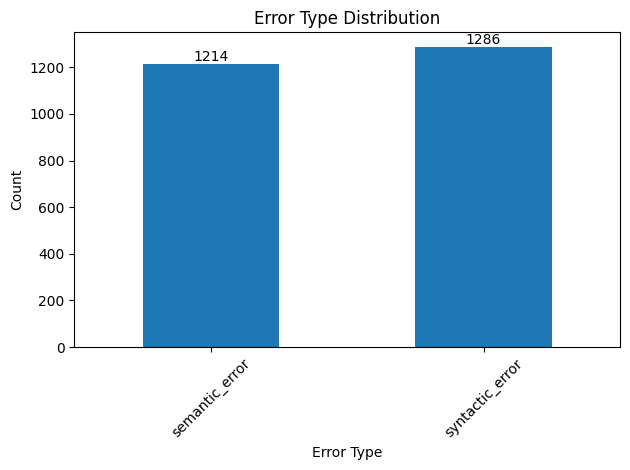

In [108]:
import matplotlib.pyplot as plt

ax = df_combined.groupby("error_type").size().plot(kind="bar")

# add counts on bars
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.title("Error Type Distribution")
plt.xlabel("Error Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

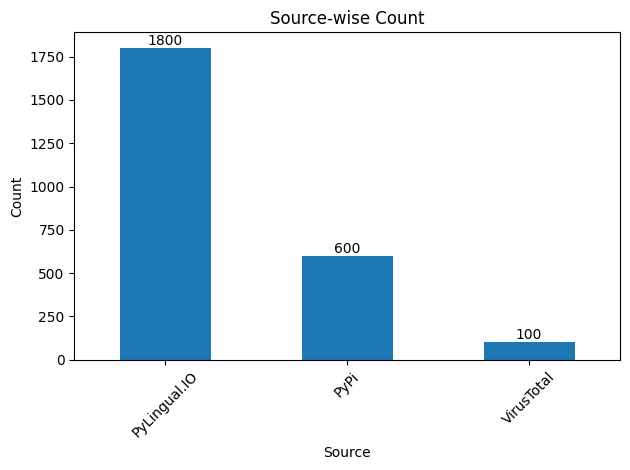

In [111]:
import matplotlib.pyplot as plt

ax = df_combined.groupby("source").size().plot(kind="bar")

# annotate counts
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha="center", va="bottom"
    )

plt.title("Source-wise Count")
plt.xlabel("Source")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()